In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [2]:
X_train = pd.read_csv("X_train_final_KUSURSUZ.csv")
X_test  = pd.read_csv("X_test_final_KUSURSUZ.csv")

y_train = pd.read_csv("y_train_encoded_final_KUSURSUZ.csv")["Kingdom_Encoded"]
y_test  = pd.read_csv("y_test_encoded_final_KUSURSUZ.csv")["Kingdom_Encoded"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape, "| unique:", y_train.nunique(), "| min/max:", y_train.min(), y_train.max())
print("y_test :", y_test.shape,  "| unique:", y_test.nunique(),  "| min/max:", y_test.min(),  y_test.max())

display(X_train.head())
display(y_train.head())


X_train: (10422, 66)
X_test : (2606, 66)
y_train: (10422,) | unique: 11 | min/max: 0 10
y_test : (2606,) | unique: 11 | min/max: 0 10


,DNAtype,Ncodons,UUU,UUC,UUA,UUG,CUU,CUC,CUA,CUG,...,CGG,AGA,AGG,GAU,GAC,GAA,GAG,UAA,UAG,UGA
0,0.910093,-0.062642,5.058891,-1.610835,1.659643,7.393991,-1.353206,-1.144576,-0.671603,-0.891852,...,-0.371385,0.161263,1.536117,-0.420016,-1.597336,-1.438210,-0.343836,0.338408,1.120308,0.273677
1,-0.531395,-0.110931,-0.892977,1.342811,-0.815257,-0.330819,-1.123895,-0.415093,-0.524157,1.486119,...,0.567714,-0.906231,-0.646929,0.953082,0.926270,-0.382764,1.789139,-0.311003,-0.336485,-0.554030
2,2.351581,-0.126515,2.272050,-0.161035,1.181751,0.806385,0.918019,-1.121972,-0.220152,-0.401169,...,-0.529915,0.912854,-0.387526,0.239822,-1.176479,0.762611,-1.050167,-0.920884,1.549440,-0.601689
3,0.910093,-0.126496,-0.087624,-0.097553,-0.246131,-0.261962,0.798131,2.530919,2.705995,-0.349868,...,-0.532935,-1.159893,-1.000091,-1.601804,-1.330357,-1.227679,-1.247887,1.270170,0.431436,1.285210
4,-0.531395,-0.120793,0.769559,-1.189621,0.095151,2.314767,-0.369358,-0.865797,-0.552735,-0.656469,...,-0.172091,0.099022,0.282858,1.996984,-0.557888,-0.571685,0.426405,-0.147238,0.103940,-0.535551


0     2
1     2
2     6
3    10
4     9
Name: Kingdom_Encoded, dtype: int64

In [3]:
codon_cols = X_train.columns[2:]  # DNAtype ve Ncodons hariç (senin kodun)
print("Kodon sayısı:", len(codon_cols))
print("İlk 10 kodon kolonu:", list(codon_cols[:10]))


Kodon sayısı: 64
İlk 10 kodon kolonu: ['UUU', 'UUC', 'UUA', 'UUG', 'CUU', 'CUC', 'CUA', 'CUG', 'AUU', 'AUC']


In [4]:
aa_table = {
    'UUU':'F','UUC':'F','UUA':'L','UUG':'L','CUU':'L','CUC':'L','CUA':'L','CUG':'L',
    'AUU':'I','AUC':'I','AUA':'I','AUG':'M','GUU':'V','GUC':'V','GUA':'V','GUG':'V',
    'GCU':'A','GCC':'A','GCA':'A','GCG':'A','CCU':'P','CCC':'P','CCA':'P','CCG':'P',
    'UGG':'W','GGU':'G','GGC':'G','GGA':'G','GGG':'G','UCU':'S','UCC':'S','UCA':'S',
    'UCG':'S','AGU':'S','AGC':'S','ACU':'T','ACC':'T','ACA':'T','ACG':'T',
    'UAU':'Y','UAC':'Y','CAA':'Q','CAG':'Q','AAU':'N','AAC':'N','UGU':'C','UGC':'C',
    'CAU':'H','CAC':'H','AAA':'K','AAG':'K','CGU':'R','CGC':'R','CGA':'R','CGG':'R',
    'AGA':'R','AGG':'R','GAU':'D','GAC':'D','GAA':'E','GAG':'E',
    'UAA':'*','UAG':'*','UGA':'*'
}
print("aa_table size:", len(aa_table))


aa_table size: 64


In [5]:
def compute_rscu(df, codon_cols, aa_table):
    df_rscu = df.copy()

    aa_to_codons = {}
    for codon, aa in aa_table.items():
        if aa == "*":
            continue
        aa_to_codons.setdefault(aa, []).append(codon)

    for aa, codons in aa_to_codons.items():
        valid = [c for c in codons if c in df_rscu.columns]
        if not valid:
            continue

        total = df_rscu[valid].sum(axis=1)

        for c in valid:
            df_rscu[f"RSCU_{c}"] = np.where(
                total > 0,
                df_rscu[c] * len(valid) / total,
                0
            )
    return df_rscu

In [6]:
print("RSCU hesaplanıyor...")
X_train_rscu = compute_rscu(X_train, codon_cols, aa_table)
X_test_rscu  = compute_rscu(X_test,  codon_cols, aa_table)

rscu_cols = [c for c in X_train_rscu.columns if c.startswith("RSCU_")]
print("Train RSCU kolon sayısı:", len(rscu_cols))
print("Örnek RSCU kolonları:", rscu_cols[:10])

display(X_train_rscu[[rscu_cols[0], rscu_cols[1], rscu_cols[2]]].head())


RSCU hesaplanıyor...
Train RSCU kolon sayısı: 61
Örnek RSCU kolonları: ['RSCU_UUU', 'RSCU_UUC', 'RSCU_UUA', 'RSCU_UUG', 'RSCU_CUU', 'RSCU_CUC', 'RSCU_CUA', 'RSCU_CUG', 'RSCU_AUU', 'RSCU_AUC']


,RSCU_UUU,RSCU_UUC,RSCU_UUA
0,2.934344,-0.934344,1.994605
1,-3.970255,5.970255,0.000000
2,2.152567,-0.152567,6.097460
3,0.000000,0.000000,-0.285255
4,0.000000,0.000000,0.000000


In [7]:
print("w ağırlıkları hesaplanıyor...")
train_ref = X_train_rscu[rscu_cols].mean()

w = {}
for col in rscu_cols:
    aa = col.split("_")[1]
    aa_codons = [f"RSCU_{c}" for c, a in aa_table.items() if a == aa]

    aa_codons = [c for c in aa_codons if c in train_ref.index]
    if len(aa_codons) == 0:
        w[col] = 1.0
        continue

    maxv = train_ref[aa_codons].max()
    w[col] = (train_ref[col] / maxv) if maxv > 0 else 1.0

print("w size:", len(w))
print("w sample:", list(w.items())[:5])


w ağırlıkları hesaplanıyor...
w size: 61
w sample: [('RSCU_UUU', 1.0), ('RSCU_UUC', 1.0), ('RSCU_UUA', 1.0), ('RSCU_UUG', 1.0), ('RSCU_CUU', 1.0)]


In [8]:
def compute_cai(df, w, codon_cols):
    cai_list = []

    for _idx, _row in df.iterrows():
        weights = []
        for c in codon_cols:
            col = f"RSCU_{c}"
            if col in df.columns and col in w:
                weights.append(w[col] + 1e-9)

        cai_list.append(np.exp(np.mean(np.log(weights))) if len(weights) > 0 else 0.0)

    df_out = df.copy()
    df_out["CAI"] = cai_list
    return df_out

In [9]:
print("FE (CAI) ekleniyor...")
X_train_fe = compute_cai(X_train_rscu, w, codon_cols)
X_test_fe  = compute_cai(X_test_rscu,  w, codon_cols)

print("FE tamamlandı.")
print("CAI nunique (train):", X_train_fe["CAI"].nunique())
display(X_train_fe[["CAI"]].head())

FE (CAI) ekleniyor...
FE tamamlandı.
CAI nunique (train): 1


,CAI
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0


In [10]:
X_train_fe_num = X_train_fe.select_dtypes(include=[np.number]).copy()
X_test_fe_num  = X_test_fe.select_dtypes(include=[np.number]).copy()

num_class = int(y_train.nunique())

print("FE sonrası numeric X_train:", X_train_fe_num.shape)
print("FE sonrası numeric X_test :", X_test_fe_num.shape)
print("num_class:", num_class)

FE sonrası numeric X_train: (10422, 128)
FE sonrası numeric X_test : (2606, 128)
num_class: 11


In [11]:
def plot_confusion_matrix_clear(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    plt.imshow(cm, cmap="Blues")
    plt.title(title, fontsize=14)
    plt.colorbar()

    ticks = np.arange(cm.shape[0])
    plt.xticks(ticks, ticks, rotation=90)
    plt.yticks(ticks, ticks)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=10, color="black")

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

print("plot_confusion_matrix_clear hazır.")


plot_confusion_matrix_clear hazır.


In [12]:
def make_voting_classifier(random_state=42):
    lr = LogisticRegression(max_iter=2000, n_jobs=-1, random_state=random_state)
    svm = SVC(probability=True, kernel="rbf", random_state=random_state)
    rf = RandomForestClassifier(n_estimators=300, random_state=random_state, n_jobs=-1)

    voting_clf = VotingClassifier(
        estimators=[("lr", lr), ("svm", svm), ("rf", rf)],
        voting="soft"
    )
    return voting_clf

def evaluate_voting(model, X_tr, y_tr, X_te, y_te, num_class):
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)

    acc = accuracy_score(y_te, y_pred)
    f1_micro = f1_score(y_te, y_pred, average="micro")

    roc_micro = roc_auc_score(
        y_te, y_proba,
        multi_class="ovr",
        average="micro",
        labels=np.arange(num_class)
    )

    return y_pred, y_proba, acc, f1_micro, roc_micro

def report_table(y_true, y_pred):
    rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return pd.DataFrame(rep).T

print("Voting + evaluate fonksiyonları hazır.")

Voting + evaluate fonksiyonları hazır.


In [13]:
print("FE -> Voting eğitiliyor...")

voting_fe = make_voting_classifier(random_state=42)

y_pred_v_fe, y_proba_v_fe, acc_v_fe, f1_v_fe, roc_v_fe = evaluate_voting(
    voting_fe,
    X_train_fe_num, y_train,
    X_test_fe_num,  y_test,
    num_class=num_class
)

print("FE -> Voting bitti.")
print("Accuracy:", acc_v_fe, "| F1 Micro:", f1_v_fe, "| ROC AUC Micro:", roc_v_fe)

FE -> Voting eğitiliyor...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


FE -> Voting bitti.
Accuracy: 0.8541826554105909 | F1 Micro: 0.8541826554105909 | ROC AUC Micro: 0.9872289668625858


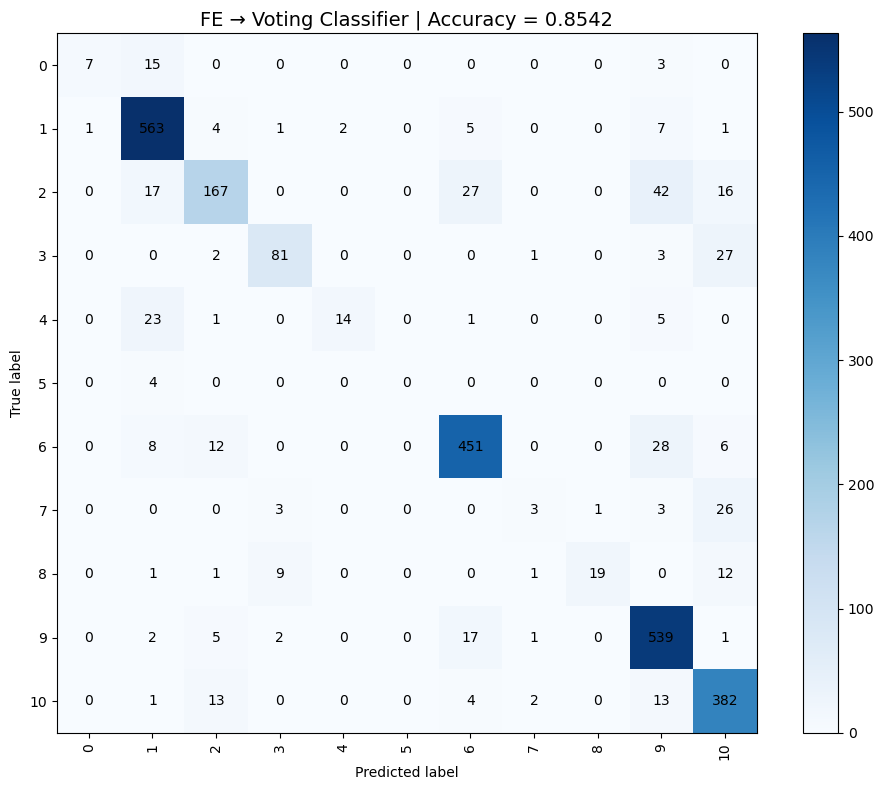

In [14]:
plot_confusion_matrix_clear(
    y_test,
    y_pred_v_fe,
    f"FE → Voting Classifier | Accuracy = {acc_v_fe:.4f}"
)

In [15]:
fe_voting_results_df = pd.DataFrame({
    "Model": ["FE → VotingClassifier"],
    "Accuracy": [acc_v_fe],
    "F1 Micro": [f1_v_fe],
    "ROC AUC Micro": [roc_v_fe]
})

display(fe_voting_results_df)


,Model,Accuracy,F1 Micro,ROC AUC Micro
0,FE → VotingClassifier,0.854183,0.854183,0.987229


In [16]:
print("--- FE → Voting SINIF BAZLI PERFORMANS ---")
display(report_table(y_test, y_pred_v_fe))


--- FE → Voting SINIF BAZLI PERFORMANS ---


,precision,recall,f1-score,support
0,0.875000,0.280000,0.424242,25.000000
1,0.888013,0.964041,0.924466,584.000000
2,0.814634,0.620818,0.704641,269.000000
3,0.843750,0.710526,0.771429,114.000000
4,0.875000,0.318182,0.466667,44.000000
5,0.000000,0.000000,0.000000,4.000000
6,0.893069,0.893069,0.893069,505.000000
7,0.375000,0.083333,0.136364,36.000000
8,0.950000,0.441860,0.603175,43.000000
9,0.838258,0.950617,0.890909,567.000000


In [17]:
k = 64  # 🔴 kritik: 128'den küçük olmalı

selector = SelectKBest(score_func=mutual_info_classif, k=k)
X_train_fs = selector.fit_transform(X_train_fe_num, y_train)
X_test_fs  = selector.transform(X_test_fe_num)

print("FS sonrası X_train:", X_train_fs.shape)
print("FS sonrası X_test :", X_test_fs.shape)


FS sonrası X_train: (10422, 64)
FS sonrası X_test : (2606, 64)


In [18]:
print("FE → FS(MI) → Voting eğitiliyor...")

voting_fefs = make_voting_classifier(random_state=42)

y_pred_v_fefs, y_proba_v_fefs, acc_v_fefs, f1_v_fefs, roc_v_fefs = evaluate_voting(
    voting_fefs,
    X_train_fs, y_train,
    X_test_fs,  y_test,
    num_class=num_class
)

print("FE → FS(MI) → Voting bitti.")
print("Accuracy:", acc_v_fefs, "| F1 Micro:", f1_v_fefs, "| ROC AUC Micro:", roc_v_fefs)


FE → FS(MI) → Voting eğitiliyor...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


FE → FS(MI) → Voting bitti.
Accuracy: 0.8553338449731389 | F1 Micro: 0.8553338449731389 | ROC AUC Micro: 0.9871866034400807


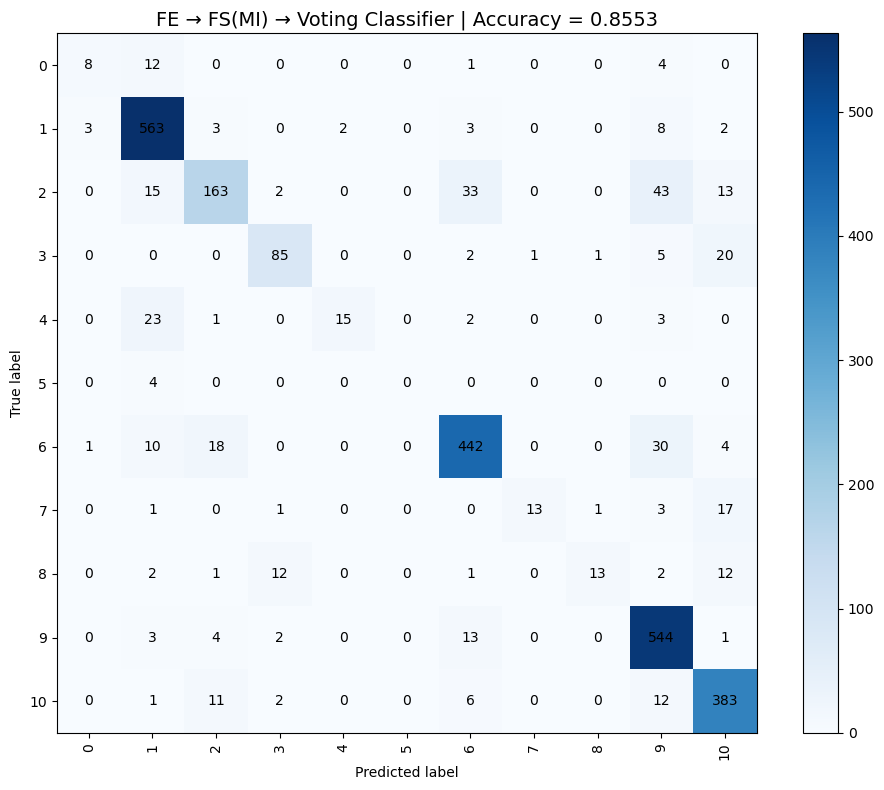

In [19]:
#bu hücrede FE → FS → Voting Classifier modelinin test karışıklık matrisini daha büyük ve daha anlaşılır şekilde çiziyorum.
#grafik başlığına doğruluk skorunu ekleyerek görsel bir özet sunuyorum.

plot_confusion_matrix_clear(
    y_test,
    y_pred_v_fefs,
    f"FE → FS(MI) → Voting Classifier | Accuracy = {acc_v_fefs:.4f}"
)

In [20]:
fefs_voting_results_df = pd.DataFrame({
    "Model": ["FE → FS(MI) → VotingClassifier"],
    "Accuracy": [acc_v_fefs],
    "F1 Micro": [f1_v_fefs],
    "ROC AUC Micro": [roc_v_fefs]
})

display(fefs_voting_results_df)


,Model,Accuracy,F1 Micro,ROC AUC Micro
0,FE → FS(MI) → VotingClassifier,0.855334,0.855334,0.987187


In [21]:
print("--- FE → FS(MI) → Voting SINIF BAZLI PERFORMANS ---")
display(report_table(y_test, y_pred_v_fefs))


--- FE → FS(MI) → Voting SINIF BAZLI PERFORMANS ---


,precision,recall,f1-score,support
0,0.666667,0.320000,0.432432,25.000000
1,0.888013,0.964041,0.924466,584.000000
2,0.810945,0.605948,0.693617,269.000000
3,0.817308,0.745614,0.779817,114.000000
4,0.882353,0.340909,0.491803,44.000000
5,0.000000,0.000000,0.000000,4.000000
6,0.878728,0.875248,0.876984,505.000000
7,0.928571,0.361111,0.520000,36.000000
8,0.866667,0.302326,0.448276,43.000000
9,0.831804,0.959436,0.891073,567.000000


In [22]:
voting_comparison_df = pd.DataFrame([
    ["FE → VotingClassifier", acc_v_fe, f1_v_fe, roc_v_fe],
    ["FE → FS(MI) → VotingClassifier", acc_v_fefs, f1_v_fefs, roc_v_fefs]
], columns=["Model", "Accuracy", "F1 Micro", "ROC AUC Micro"])

display(voting_comparison_df.round(4))


,Model,Accuracy,F1 Micro,ROC AUC Micro
0,FE → VotingClassifier,0.8542,0.8542,0.9872
1,FE → FS(MI) → VotingClassifier,0.8553,0.8553,0.9872


In [23]:
selected_idx = selector.get_support(indices=True)
selected_features = X_train_fe_num.columns[selected_idx]

print("Seçilen feature sayısı:", len(selected_features))
print("İlk 30 seçilen feature:", list(selected_features[:30]))


Seçilen feature sayısı: 64
İlk 30 seçilen feature: ['DNAtype', 'Ncodons', 'UUC', 'UUA', 'UUG', 'CUC', 'CUA', 'AUC', 'AUA', 'AUG', 'GUG', 'GCC', 'GCG', 'CCA', 'CCG', 'UGG', 'GGU', 'GGC', 'UCU', 'UCA', 'UCG', 'AGU', 'ACC', 'ACA', 'ACG', 'CAG', 'AAU', 'UGU', 'UGC', 'AAA']


In [27]:
# Encoding sırasına göre sınıf isimleri
target_names = [
    "arc",  # 0
    "bct",  # 1
    "inv",  # 2
    "mam",  # 3
    "phg",  # 4
    "plm",  # 5
    "pln",  # 6
    "pri",  # 7
    "rod",  # 8
    "vrl",  # 9
    "vrt"   # 10
]

print("target_names:", target_names)


target_names: ['arc', 'bct', 'inv', 'mam', 'phg', 'plm', 'pln', 'pri', 'rod', 'vrl', 'vrt']


In [39]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

def print_general_and_class_report_named(y_true, y_pred, model_name="MODEL", target_names=None):
    print(f"{model_name} GENEL PERFORMANS")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred, average="weighted", zero_division=0), 4))
    print("Recall   :", round(recall_score(y_true, y_pred, average="weighted", zero_division=0), 4))
    print("F1 Score :", round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4))
    print(f"\n{model_name} SINIF BAZLI PERFORMANS")
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))


In [40]:
print_general_and_class_report_named(
    y_test,
    y_pred_v_fefs,
    model_name="FE → FS(MI) → Voting",
    target_names=target_names
)


FE → FS(MI) → Voting GENEL PERFORMANS
Accuracy : 0.8553
Precision: 0.8531
Recall   : 0.8553
F1 Score : 0.8444

FE → FS(MI) → Voting SINIF BAZLI PERFORMANS
              precision    recall  f1-score   support

         arc       0.67      0.32      0.43        25
         bct       0.89      0.96      0.92       584
         inv       0.81      0.61      0.69       269
         mam       0.82      0.75      0.78       114
         phg       0.88      0.34      0.49        44
         plm       0.00      0.00      0.00         4
         pln       0.88      0.88      0.88       505
         pri       0.93      0.36      0.52        36
         rod       0.87      0.30      0.45        43
         vrl       0.83      0.96      0.89       567
         vrt       0.85      0.92      0.88       415

    accuracy                           0.86      2606
   macro avg       0.77      0.58      0.63      2606
weighted avg       0.85      0.86      0.84      2606



In [42]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


In [44]:
def plot_multiclass_roc(y_true, y_proba, class_names, title):
    """
    y_true      : gerçek etiketler (0,1,2,...)
    y_proba     : predict_proba çıktısı (N x num_class)
    class_names : ["arc","bct",...]
    """
    n_classes = len(class_names)

    # One-vs-Rest için y_true'yu binarize et
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

    plt.figure(figsize=(8, 6))

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{class_names[i]} (AUC={roc_auc:.2f})")

    # rastgele tahmin çizgisi
    plt.plot([0, 1], [0, 1], "k--", lw=1)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(fontsize=8, loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [46]:
target_names = [
    "arc", "bct", "inv", "mam", "phg",
    "plm", "pln", "pri", "rod", "vrl", "vrt"
]
print("target_names hazır:", target_names)


target_names hazır: ['arc', 'bct', 'inv', 'mam', 'phg', 'plm', 'pln', 'pri', 'rod', 'vrl', 'vrt']


In [47]:
y_proba_v_fe = voting_fe.predict_proba(X_test_fe_num)
print("y_proba_v_fe shape:", y_proba_v_fe.shape)


y_proba_v_fe shape: (2606, 11)


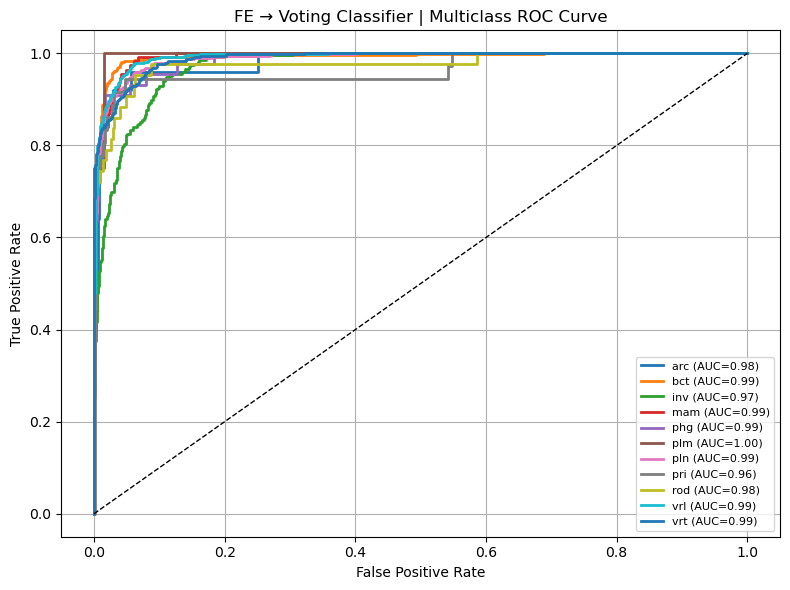

In [48]:
plot_multiclass_roc(
    y_test,
    y_proba_v_fe,
    class_names=target_names,
    title="FE → Voting Classifier | Multiclass ROC Curve"
)


In [49]:
y_proba_v_fefs = voting_fefs.predict_proba(X_test_fs)
print("y_proba_v_fefs shape:", y_proba_v_fefs.shape)


y_proba_v_fefs shape: (2606, 11)


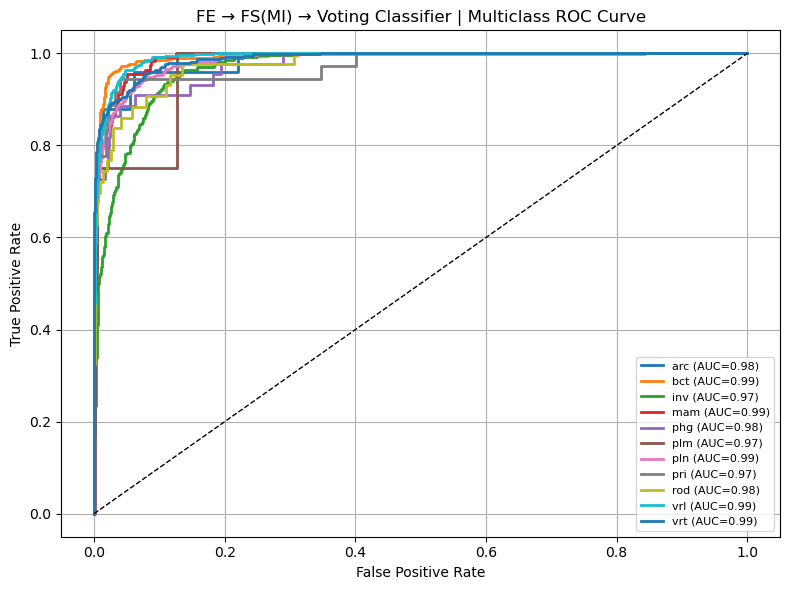

In [50]:
plot_multiclass_roc(
    y_test,
    y_proba_v_fefs,
    class_names=target_names,
    title="FE → FS(MI) → Voting Classifier | Multiclass ROC Curve"
)
